In [2]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 6.22汇报时的参数全探索基础上 修改scale2=0.0005 无噪声 初始值随机

In [3]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10              # 每个参数组合运行的次数
c2tsc = 0.8              # 固定 c2tsc
scale2 = 0.0005          # 固定 scale2


Jet_max = 1.98 * 75   # 148.5
Jer_max = 3.24 * 50   # 162

# 对数间隔：小值变化更精细
Jet_list = np.logspace(np.log10(6.5), np.log10(Jet_max), 50)  # 从 0.1 开始，避免 0
#Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 8)  # 从 0.1 开始，避免 0
#Jet_list = np.insert(Jet_list, 0, 0)  # 如果想包含 0，手动加上

Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)
#Jer_list = np.insert(Jer_list, 0, 0)
Jer_list = [Jer_list[-2]]

print(f"Jet 范围: {Jet_list}")
print(f"Jer 范围: {Jer_list}")
print(f"总参数组合数: {len(Jet_list) * len(Jer_list)}")
print(f"总运行次数: {len(Jet_list) * len(Jer_list) * n_runs}")



Jet 范围: [  6.5          6.92858001   7.3854186    7.87237902   8.39144736
   8.94474068   9.5345156   10.16317756  10.83329059  11.54758778
  12.30898244  13.12057994  13.98569043  14.90784232  15.89079665
  16.93856245  18.05541309  19.24590371  20.51488979  21.86754695
  23.30939209  24.84630584  26.48455659  28.23082604  30.09223643
  32.07637964  34.19134809  36.44576781  38.84883355  41.41034636
  44.14075351  47.0511911   50.15352952  53.46042182  56.98535534
  60.7427067   64.74780048  69.01697165  73.56763228  78.41834247
  83.5888861   89.10035152  94.97521753 101.2374451  107.91257506
 115.02783228 122.61223674 130.69672182 139.31426054 148.5       ]
Jer 范围: [71.26925764953582]
总参数组合数: 50
总运行次数: 500


In [4]:

# 创建保存目录
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005"
os.makedirs(DATA_DIR, exist_ok=True)

# 统计已完成文件，支持断点续跑
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

total_tasks = len(Jet_list) * len(Jer_list) * n_runs
completed = 0
skipped = 0

for Jet_val in Jet_list:
    for Jer_val in Jer_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(DATA_DIR, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                skipped += 1
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet_val
            params["Jer"] = Jer_val
            
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "Jet": Jet_val,
                "Jer": Jer_val,
                "seed": seed
            })
            completed += 1
            print(f"Saved: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed} (已完成 {completed})")

print(f"\n完成！新运行: {completed}, 跳过: {skipped}")
print(f"数据保存在: {DATA_DIR}")

已存在 800 个文件，将跳过它们
Saved: Jet=6.5000, Jer=71.2693, seed=1 (已完成 1)
Saved: Jet=6.5000, Jer=71.2693, seed=2 (已完成 2)
Saved: Jet=6.5000, Jer=71.2693, seed=3 (已完成 3)
Saved: Jet=6.5000, Jer=71.2693, seed=4 (已完成 4)
Saved: Jet=6.5000, Jer=71.2693, seed=5 (已完成 5)
Saved: Jet=6.5000, Jer=71.2693, seed=6 (已完成 6)
Saved: Jet=6.5000, Jer=71.2693, seed=7 (已完成 7)
Saved: Jet=6.5000, Jer=71.2693, seed=8 (已完成 8)
Saved: Jet=6.5000, Jer=71.2693, seed=9 (已完成 9)
Saved: Jet=6.5000, Jer=71.2693, seed=10 (已完成 10)
Saved: Jet=6.9286, Jer=71.2693, seed=1 (已完成 11)
Saved: Jet=6.9286, Jer=71.2693, seed=2 (已完成 12)
Saved: Jet=6.9286, Jer=71.2693, seed=3 (已完成 13)
Saved: Jet=6.9286, Jer=71.2693, seed=4 (已完成 14)
Saved: Jet=6.9286, Jer=71.2693, seed=5 (已完成 15)
Saved: Jet=6.9286, Jer=71.2693, seed=6 (已完成 16)
Saved: Jet=6.9286, Jer=71.2693, seed=7 (已完成 17)
Saved: Jet=6.9286, Jer=71.2693, seed=8 (已完成 18)
Saved: Jet=6.9286, Jer=71.2693, seed=9 (已完成 19)
Saved: Jet=6.9286, Jer=71.2693, seed=10 (已完成 20)
Saved: Jet=7.3854, Jer=71.269

In [5]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 去掉threshold 只有一个最终版本

In [6]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer_scale0x0005"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_CSV = f"data/analysis_data/spindles_{DATA_FOLDER}_explore_1.csv"

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase):
    """处理纺锤波检测结果，返回列表"""
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
            "phase_at_end": slow_phase[end_idx],
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出文件: {OUTPUT_CSV}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        PARAM1_NAME: Jet_val,
        PARAM2_NAME: Jer_val,
        "seed": seed,
    }
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印参数范围
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 1290 个文件
限定 Jet 范围: (0, 148.5)
限定 Jer 范围: (0, 162)
输出文件: data/analysis_data/spindles_Jet_Jer_scale0x0005_explore_1.csv
Processing: Jet=0.1000, Jer=0.1000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=9, 慢=11
Processing: Jet=0.1000, Jer=0.1000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=9, 慢=8
Processing: Jet=0.1000, Jer=0.1000, seed=2
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成：快=2, 慢=4
Processing: Jet=94.9752, Jer=71.2693, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=3, 慢=4
Processing: Jet=94.9752, Jer=71.2693, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=3, 慢=5

总共检测到 13703 个纺锤波
快纺锤波: 7035
慢纺锤波: 6668
CSV 已保存: data/analysis_data/spindles_Jet_Jer_scale0x0005_explore_1.csv

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.000500 ~ 0.000500
  Jet: 0.1000 ~ 148.5000
  Jer: 0.1000 ~ 162.0000

前几行:
   c2tsc  scale2  Jet  Jer  seed  type    start  peak_time      end  duration  \
0    0.8  0.0005  0.1  0.1     1  fast   3.4222     3.6498   4.1711    0.7489   
1    0.8  0.0005  0.1  0.1     1  fast   4.7908     5.0961   5.5933    0.8025   
2    0.8  0.0005  0.1  0.1     1  fast   7.1261     7.6479   7.7734    0.6473   
3    0.8  0.0005  0.1  0.1     1  fast   8.6607     8.8288   9.1223    0.4616   
4    0.8  0.0005  0.1  0.1     1  fast  13.0355    13.2223  13.4415    0.4060   

   frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  
0  12.677812   4.061394        2.372179      -1.552022      2.928575  
1  12.276117   3.393169       -1.596297       0.145189     -2.101644  
2  12.086907   4.003872        3.011149      -1.163689   

#### 画图

总纺锤波数: 8676
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

使用的 Jet 值: [0.1, 0.2839, 0.8058, 2.2872, 6.4925, 18.4297, 52.3146, 148.5]
使用的 Jer 值: [0.1, 0.2273, 0.5167, 1.1745, 2.6696, 6.0683, 13.7936, 31.3537, 71.2693, 162.0]

原始有效参数组合数: 79
过滤后有效参数组合数: 79


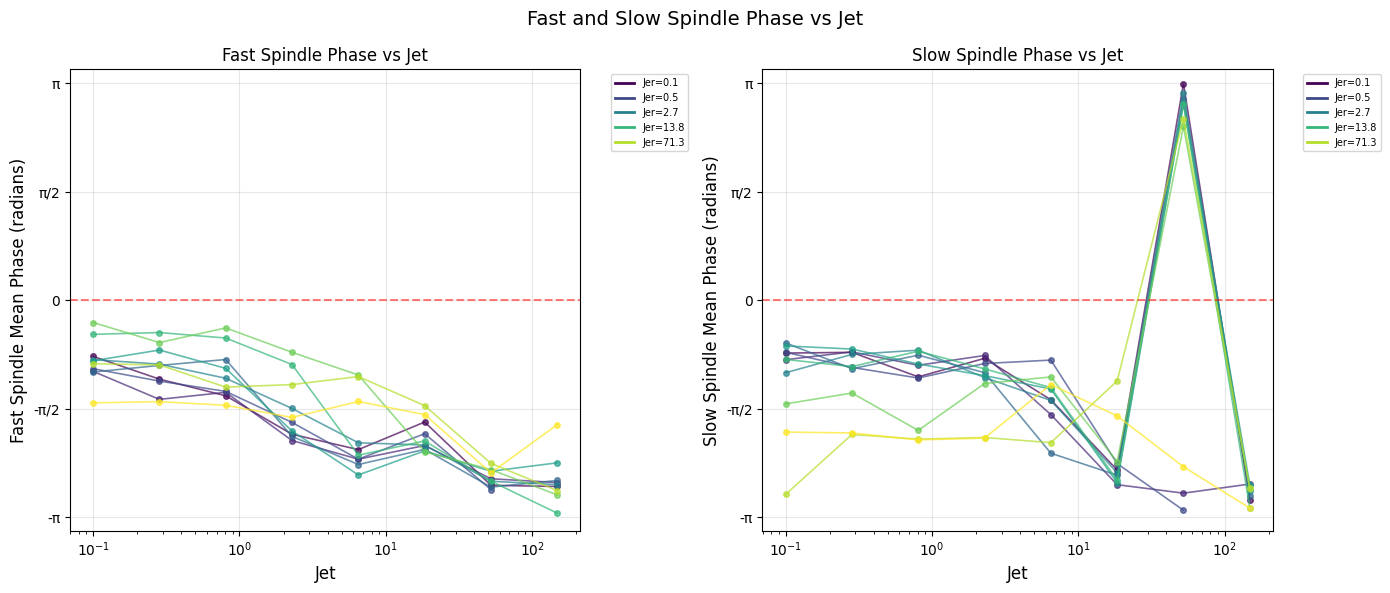

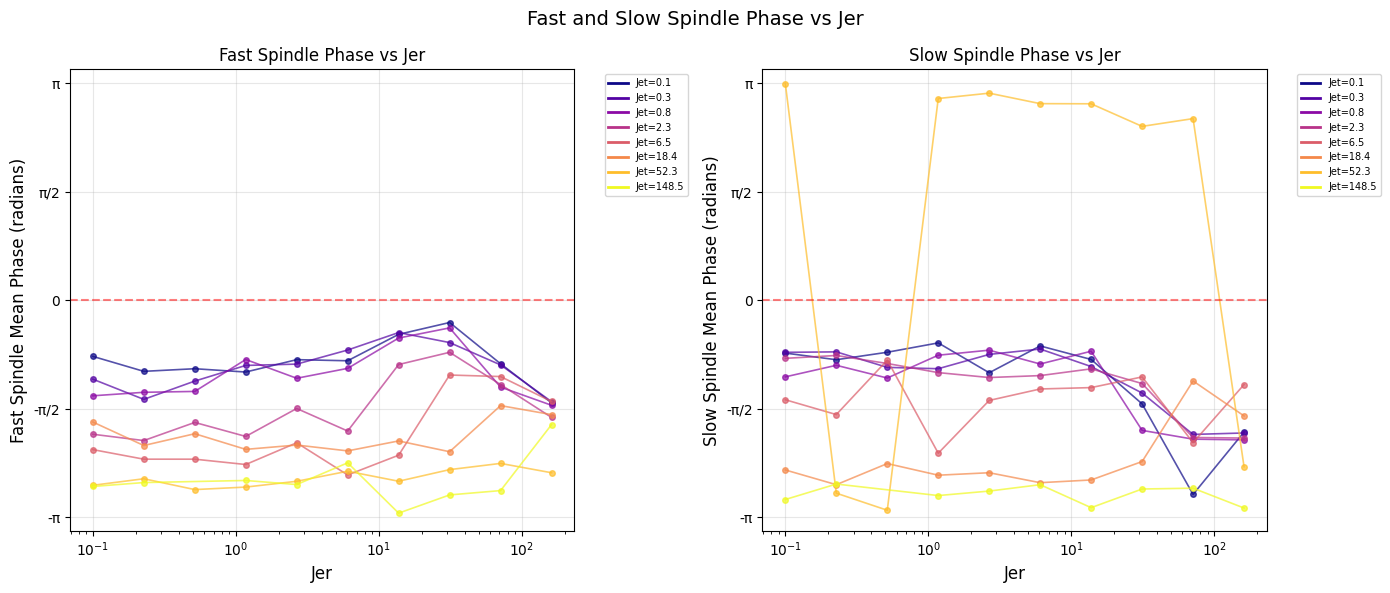

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 和 Jer 值 ==========
Jet_values_all = sorted(df['Jet'].unique())
Jer_values_all = sorted(df['Jer'].unique())

# 去掉你不想显示的值（修改这里即可）
Jet_values_all = Jet_values_all#[:-1]  # 去掉最后一个（最大值）
Jer_values_all = Jer_values_all#[:-1]  # 去掉最后一个（最大值）

print(f"\n使用的 Jet 值: {Jet_values_all}")
print(f"使用的 Jer 值: {Jer_values_all}")

# ========== 计算每个 (Jet, Jer) 组合下快慢纺锤波的相位 ==========
fast_phase = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_phase')

slow_phase = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_phase')

fast_std = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_std')

slow_std = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_std')

# 合并
phase_df = pd.merge(fast_phase, slow_phase, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, fast_std, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, slow_std, on=['Jet', 'Jer'])
phase_df['phase_diff'] = phase_df['fast_phase'] - phase_df['slow_phase']
phase_df = phase_df.dropna()

# ========== 关键：用 Jet_values_all 和 Jer_values_all 过滤 phase_df ==========
phase_df_filtered = phase_df[
    (phase_df['Jet'].isin(Jet_values_all)) & 
    (phase_df['Jer'].isin(Jer_values_all))
].copy()

print(f"\n原始有效参数组合数: {len(phase_df)}")
print(f"过滤后有效参数组合数: {len(phase_df_filtered)}")

# ========== 图2：快慢纺锤波各自的相位 vs Jet ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_values_all)))

# 左图：快纺锤波相位 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['fast_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Jer={Jer_values_all[i]:.1f}') 
                   for i in range(0, len(Jer_values_all), max(1, len(Jer_values_all)//5))]
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['slow_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jet', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢纺锤波各自的相位 vs Jer ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_values_all)))

# 左图：快纺锤波相位 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['fast_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

legend_elements2 = [Line2D([0], [0], color=colors2[i], lw=2, label=f'Jet={Jet_values_all[i]:.1f}') 
                    for i in range(0, len(Jet_values_all), max(1, len(Jet_values_all)//5))]
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['slow_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jer', fontsize=14)
plt.tight_layout()
plt.show()

总纺锤波数: 13703
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 71.3, 实际最近值: 71.2693


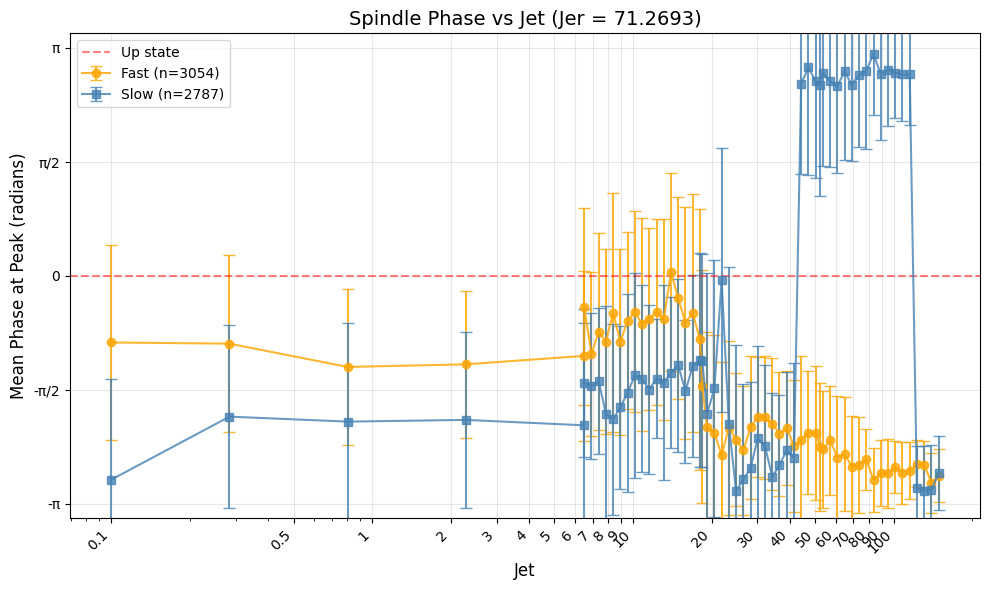


统计摘要 (Jer = 71.2693)
Jet=0.1000: Fast mean=-0.920±1.348 rad (n=60) Slow mean=-2.811±1.385 rad (n=39)
Jet=0.2839: Fast mean=-0.936±1.218 rad (n=67) Slow mean=-1.942±1.263 rad (n=38)
Jet=0.8058: Fast mean=-1.257±1.077 rad (n=65) Slow mean=-2.011±1.358 rad (n=44)
Jet=2.2872: Fast mean=-1.221±1.014 rad (n=62) Slow mean=-1.987±1.214 rad (n=41)
Jet=6.4925: Fast mean=-1.105±1.168 rad (n=72) Slow mean=-2.061±1.406 rad (n=43)
Jet=6.5000: Fast mean=-0.425±1.359 rad (n=72) Slow mean=-1.482±1.019 rad (n=45)
Jet=6.9286: Fast mean=-1.078±1.133 rad (n=69) Slow mean=-1.524±1.007 rad (n=50)
Jet=7.3854: Fast mean=-0.769±1.360 rad (n=68) Slow mean=-1.452±1.009 rad (n=41)
Jet=7.8724: Fast mean=-0.911±1.276 rad (n=68) Slow mean=-1.902±1.489 rad (n=44)
Jet=8.3914: Fast mean=-0.507±1.652 rad (n=69) Slow mean=-1.979±1.314 rad (n=45)
Jet=8.9447: Fast mean=-0.914±1.279 rad (n=66) Slow mean=-1.813±1.120 rad (n=47)
Jet=9.5345: Fast mean=-0.619±1.220 rad (n=64) Slow mean=-1.613±1.362 rad (n=48)
Jet=10.1632: Fast 

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_explore_1.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 值 ==========
Jet_values = sorted(df['Jet'].unique())

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 71.3
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 计算该 Jer 下每个 Jet 的快慢纺锤波相位 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

fast_means = []
fast_stds = []
slow_means = []
slow_stds = []
fast_ns = []
slow_ns = []
jet_vals = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    # 快纺锤波
    fast_phases = subset[subset['type'] == 'fast']['phase_at_peak'].dropna().values
    if len(fast_phases) > 0:
        m, s = circular_stats(fast_phases)
        fast_means.append(m)
        fast_stds.append(s)
        fast_ns.append(len(fast_phases))
    else:
        fast_means.append(np.nan)
        fast_stds.append(np.nan)
        fast_ns.append(0)
    
    # 慢纺锤波
    slow_phases = subset[subset['type'] == 'slow']['phase_at_peak'].dropna().values
    if len(slow_phases) > 0:
        m, s = circular_stats(slow_phases)
        slow_means.append(m)
        slow_stds.append(s)
        slow_ns.append(len(slow_phases))
    else:
        slow_means.append(np.nan)
        slow_stds.append(np.nan)
        slow_ns.append(0)
    
    jet_vals.append(jet_val)

jet_vals = np.array(jet_vals)
fast_means = np.array(fast_means)
fast_stds = np.array(fast_stds)
slow_means = np.array(slow_means)
slow_stds = np.array(slow_stds)

valid_fast = ~np.isnan(fast_means)
valid_slow = ~np.isnan(slow_means)

# ========== 画图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

# 快纺锤波（带误差棒）
if np.any(valid_fast):
    ax.errorbar(jet_vals[valid_fast], fast_means[valid_fast], 
                yerr=fast_stds[valid_fast],
                fmt='o-', color='orange', capsize=4, 
                label=f'Fast (n={sum(fast_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

# 慢纺锤波（带误差棒）
if np.any(valid_slow):
    ax.errorbar(jet_vals[valid_slow], slow_means[valid_slow], 
                yerr=slow_stds[valid_slow],
                fmt='s-', color='steelblue', capsize=4, 
                label=f'Slow (n={sum(slow_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Mean Phase at Peak (radians)', fontsize=12)
ax.set_title(f'Spindle Phase vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xscale('log')

# ========== 设置更细致的横坐标刻度 ==========
# 生成从 1 到 200 的刻度值（对数坐标下均匀分布）
xticks_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
# 只保留在 Jet 范围内的刻度
xticks_values = [v for v in xticks_values if v >= min(jet_vals) and v <= max(jet_vals)]
# 如果最小 Jet 小于 1，添加 0.1 和 0.5
if min(jet_vals) < 1:
    xticks_values = [0.1, 0.5] + xticks_values
ax.set_xticks(xticks_values)
ax.set_xticklabels([str(v) for v in xticks_values], rotation=45, ha='right')

ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Up state')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)

for jet, fm, fs, sm, ss, fn, sn in zip(jet_vals, fast_means, fast_stds, slow_means, slow_stds, fast_ns, slow_ns):
    if not np.isnan(fm) or not np.isnan(sm):
        line = f"Jet={jet:.4f}:"
        if not np.isnan(fm):
            line += f" Fast mean={fm:.3f}±{fs:.3f} rad (n={fn})"
        if not np.isnan(sm):
            line += f" Slow mean={sm:.3f}±{ss:.3f} rad (n={sn})"
        print(line)

总纺锤波数: 13703
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 71.3, 实际最近值: 71.2693


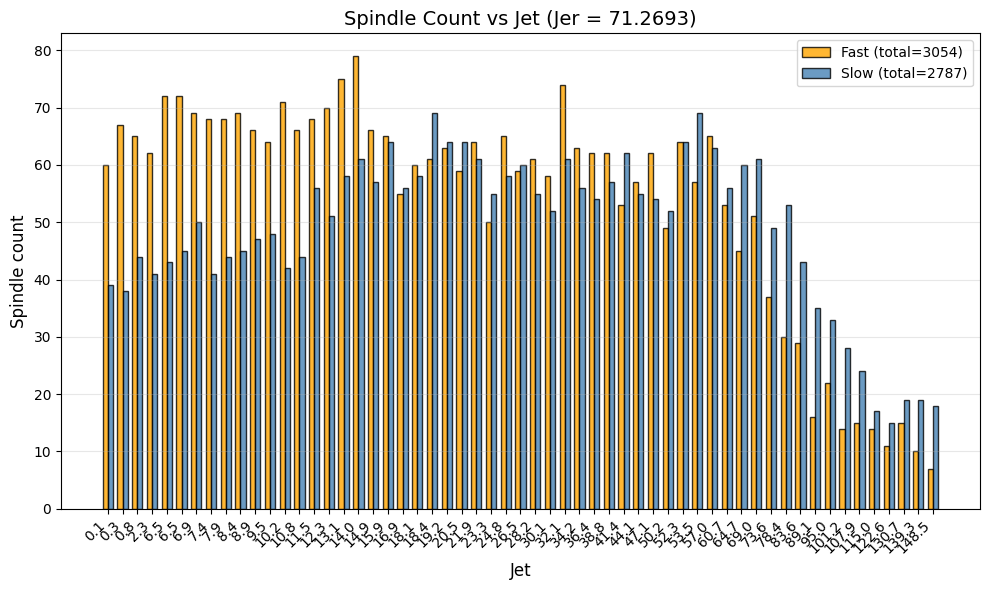


统计摘要 (Jer = 71.2693)
       Jet     Fast     Slow    Total
--------------------------------------
       0.1       60       39       99
       0.3       67       38      105
       0.8       65       44      109
       2.3       62       41      103
       6.5       72       43      115
       6.5       72       45      117
       6.9       69       50      119
       7.4       68       41      109
       7.9       68       44      112
       8.4       69       45      114
       8.9       66       47      113
       9.5       64       48      112
      10.2       71       42      113
      10.8       66       44      110
      11.5       68       56      124
      12.3       70       51      121
      13.1       75       58      133
      14.0       79       61      140
      14.9       66       57      123
      15.9       65       64      129
      16.9       55       56      111
      18.1       60       58      118
      18.4       61       69      130
      19.2       63       6

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_explore_1.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 71.3
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

# ========== 统计每个 Jet 下的快慢纺锤波个数 ==========
jet_vals = []
fast_counts = []
slow_counts = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    
    jet_vals.append(jet_val)
    fast_counts.append(fast_count)
    slow_counts.append(slow_count)

jet_vals = np.array(jet_vals)
fast_counts = np.array(fast_counts)
slow_counts = np.array(slow_counts)

# ========== 画图：快慢纺锤波个数随 Jet 变化 ==========
fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
x = np.arange(len(jet_vals))

ax.bar(x - width/2, fast_counts, width, color='orange', edgecolor='black', 
       label=f'Fast (total={sum(fast_counts)})', alpha=0.8)
ax.bar(x + width/2, slow_counts, width, color='steelblue', edgecolor='black', 
       label=f'Slow (total={sum(slow_counts)})', alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title(f'Spindle Count vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in jet_vals], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)
print(f"{'Jet':>10} {'Fast':>8} {'Slow':>8} {'Total':>8}")
print("-"*38)
for j, fc, sc in zip(jet_vals, fast_counts, slow_counts):
    print(f"{j:>10.1f} {fc:>8} {sc:>8} {fc+sc:>8}")
print("-"*38)
print(f"{'Total':>10} {sum(fast_counts):>8} {sum(slow_counts):>8} {sum(fast_counts)+sum(slow_counts):>8}")

总纺锤波数: 8676
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jet: 52.3, 实际最近值: 52.3146
目标 Jer: 71.3, 实际最近值: 71.2693

筛选后的纺锤波总数: 128
快纺锤波: 64
慢纺锤波: 64
包含的 seed: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

快纺锤波 phase_at_peak 数量: 64
慢纺锤波 phase_at_peak 数量: 64


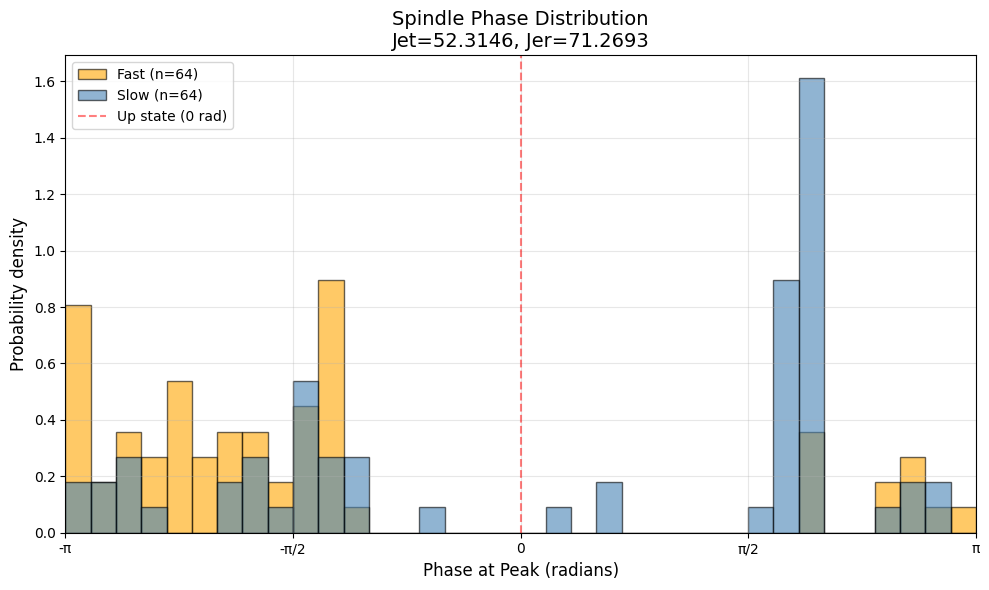

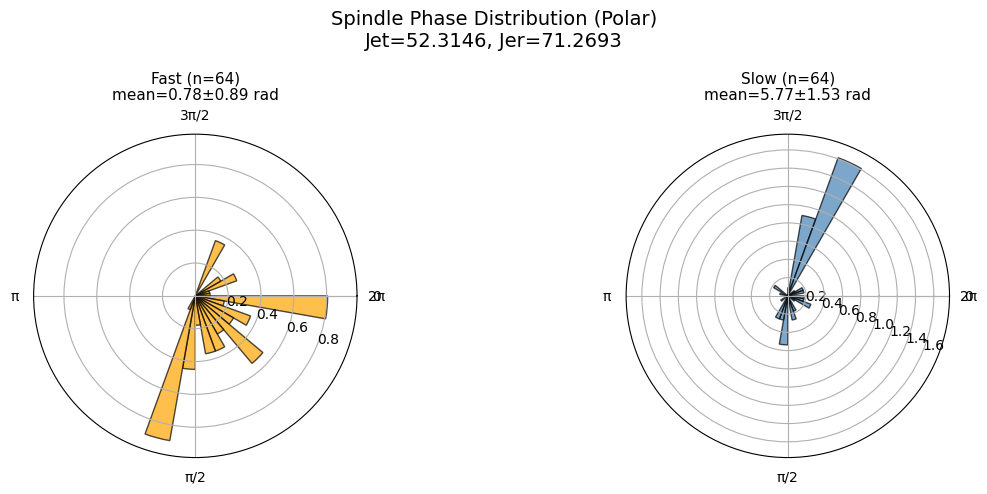

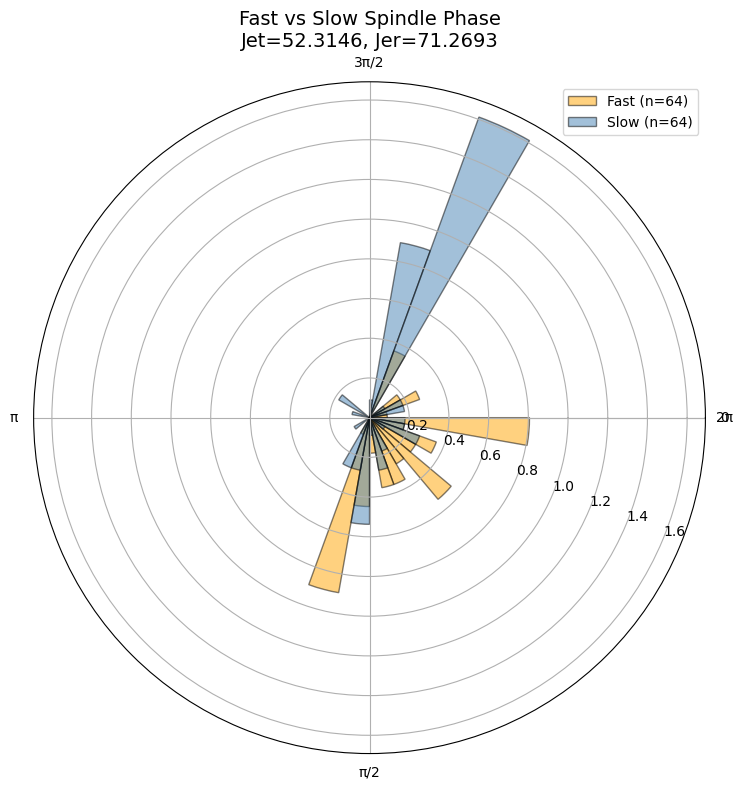


统计摘要
Fast: n=64, mean=-2.362 rad, std=0.886 rad
Slow: n=64, mean=2.628 rad, std=1.527 rad


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近的目标值 ==========
target_Jet = 52.3
target_Jer = 71.3

all_Jet_values = sorted(df['Jet'].unique())
all_Jer_values = sorted(df['Jer'].unique())

closest_Jet = min(all_Jet_values, key=lambda x: abs(x - target_Jet))
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))

print(f"\n目标 Jet: {target_Jet}, 实际最近值: {closest_Jet:.4f}")
print(f"目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选目标参数 ==========
df_filtered = df[(np.abs(df['Jet'] - closest_Jet) < 1e-6) & 
                 (np.abs(df['Jer'] - closest_Jer) < 1e-6)]

print(f"\n筛选后的纺锤波总数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

# 显示有哪些 seed
seeds = sorted(df_filtered['seed'].unique())
print(f"包含的 seed: {seeds}")

# ========== 提取 phase_at_peak ==========
fast_phases = df_filtered[df_filtered['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = df_filtered[df_filtered['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波 phase_at_peak 数量: {len(fast_phases)}")
print(f"慢纺锤波 phase_at_peak 数量: {len(slow_phases)}")

# ========== 将相位从 -π~π 转换到 0~2π ==========
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# ========== 图1：线性直方图（叠加对比）==========
fig, ax = plt.subplots(figsize=(10, 6))

if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='orange', edgecolor='black', density=True, 
            label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, 
            label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Spindle Phase Distribution\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state (0 rad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：极坐标直方图（左右并排）==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'orange'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.suptitle(f'Spindle Phase Distribution (Polar)\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢叠加在同一极坐标图上 ==========
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='orange', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title(f'Fast vs Slow Spindle Phase\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for name, phases in [('Fast', fast_phases), ('Slow', slow_phases)]:
    if len(phases) > 0:
        mean_p = circmean(phases, low=-np.pi, high=np.pi)
        std_p = circstd(phases, low=-np.pi, high=np.pi)
        print(f"{name}: n={len(phases)}, mean={mean_p:.3f} rad, std={std_p:.3f} rad")
    else:
        print(f"{name}: 无数据")